In [ ]:
# Code for Noise Ablation Study: Cosine T=1000|| Linear T=1000 || Cosine T=500

# ── Cell 1: Install and mount ─────────────────────────────
# Safe remount — always run this first
import os, shutil, subprocess
from google.colab import drive

subprocess.run(['fusermount', '-uz', '/content/drive'], capture_output=True)
shutil.rmtree('/content/drive', ignore_errors=True)
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive')

!pip install diffusers accelerate torchvision torch-fidelity -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.8 MB/s eta 0:00:00


In [ ]:
# ── Cell 2: Imports ────────────────────────────────────────
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from diffusers import DDPMPipeline, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from torchvision import transforms
from torch_fidelity import calculate_metrics
import matplotlib.pyplot as plt
import shutil, random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"GPU: {torch.cuda.get_device_name(0)}")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GPU: Tesla T4


In [ ]:
# ── Cell 3: Dataset ────────────────────────────────────────
DATA_DIR   = '/content/drive/MyDrive/Dissertation2026/oasis-coronal-alzheimers'
IMAGE_SIZE = 128
BATCH_SIZE = 8

class MRIDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.files     = [f for f in os.listdir(img_dir) if f.endswith('.png')]
        self.img_dir   = img_dir
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.files[idx])).convert('L')
        return self.transform(img) if self.transform else img

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataset    = MRIDataset(DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Training images: {len(dataset)}")

Training images: 700


In [ ]:
# ── Cell 4: Function to train one DDPM variant ─────────────
def train_ddpm_variant(schedule, timesteps, output_dir, num_epochs=50):
    """
    Trains one DDPM variant with given schedule and timestep count.

    schedule  : 'squaredcos_cap_v2' (cosine) or 'linear'
    timesteps : 1000, 500, or 100
    """
    print(f"\n{'='*55}")
    print(f"Training: schedule={schedule}, T={timesteps}")
    print(f"{'='*55}")

    os.makedirs(output_dir, exist_ok=True)

    # Load fresh pretrained model each time
    pipeline  = DDPMPipeline.from_pretrained("benetraco/brain_ddpm_128")
    model     = pipeline.unet.to(device)
    scheduler = DDPMScheduler(
        num_train_timesteps=timesteps,
        beta_schedule=schedule
    )
 # code refined by Claude AI
    total_steps  = len(dataloader) * num_epochs
    optimizer    = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    lr_scheduler = get_cosine_schedule_with_warmup(
        optimizer, num_warmup_steps=100, num_training_steps=total_steps
    )
    scaler = torch.amp.GradScaler('cuda')

    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        for batch in dataloader:
            images    = batch.to(device)
            ts        = torch.randint(0, timesteps, (images.shape[0],), device=device).long()
            noise     = torch.randn_like(images)
            noisy     = scheduler.add_noise(images, noise, ts)
            with torch.amp.autocast('cuda'):
                pred = model(noisy, ts).sample
                loss = torch.nn.functional.mse_loss(pred, noise)
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            lr_scheduler.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(dataloader)
        loss_history.append(avg)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {avg:.6f}")

    pipeline.unet = model
    pipeline.save_pretrained(output_dir)
    print(f"✅ Saved to {output_dir}")
    return loss_history

In [ ]:
# ── Cell 5: Function to generate 100 images and compute FID ─
def generate_and_fid(model_dir, gen_dir, schedule, timesteps, real_dir_100):
    """Generates 100 images and computes FID against 100 real images."""
    os.makedirs(gen_dir, exist_ok=True)

    pipeline  = DDPMPipeline.from_pretrained(model_dir).to('cuda')
    scheduler = DDPMScheduler(
        num_train_timesteps=timesteps,
        beta_schedule=schedule
    )

    count = 0
    while count < 100:
        bs = min(8, 100 - count)
        with torch.no_grad():
            images = pipeline(batch_size=bs, num_inference_steps=timesteps).images
        for img in images:
            img.convert('RGB').save(f'{gen_dir}/gen_{count:03d}.png')
            count += 1
    print(f"Generated 100 images → {gen_dir}")

    metrics = calculate_metrics(
        input1=gen_dir,
        input2=real_dir_100,
        cuda=True, fid=True, verbose=False
    )
    fid = metrics['frechet_inception_distance']
    print(f"FID: {fid:.2f}")
    return fid

In [ ]:
# ── Cell 6: Create 100-image real reference set (do once) ───
REAL_REF_DIR = '/content/drive/MyDrive/Dissertation2026/ablation_real_100'
os.makedirs(REAL_REF_DIR, exist_ok=True)
 # code refined by Claude AI
if len(os.listdir(REAL_REF_DIR)) < 100:
    real_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.png')]
    random.seed(42)
    random.shuffle(real_files)
    for f in real_files[:100]:
        shutil.copy(os.path.join(DATA_DIR, f), os.path.join(REAL_REF_DIR, f))
    print(f"Created real reference: {len(os.listdir(REAL_REF_DIR))} images")
else:
    print(f"Real reference already exists: {len(os.listdir(REAL_REF_DIR))} images")

Real reference already exists: 100 images


In [ ]:
# ── Cell 7: Run all three ablation variants ──────────────────
# This is the actual ablation study
# Each variant took ~40 minutes — total ~2 hours

# Variant 1: Cosine schedule, T=1000 (existing Run 1 - previously trained model on cosine schedule)
# Recomputing FID here for a fair comparison

# Variant 2: LINEAR schedule, T=1000
train_ddpm_variant(
    schedule='linear',
    timesteps=1000,
    output_dir='/content/drive/MyDrive/Dissertation2026/ablation_linear_1000',
    num_epochs=50
)

# Variant 3: COSINE schedule, T=500 (fewer timesteps)
train_ddpm_variant(
    schedule='squaredcos_cap_v2',
    timesteps=500,
    output_dir='/content/drive/MyDrive/Dissertation2026/ablation_cosine_500',
    num_epochs=50
)

print("\n✅ All ablation variants trained!")


Training: schedule=linear, T=1000


model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  Epoch 10/50 | Loss: 0.012040
  Epoch 20/50 | Loss: 0.011336
  Epoch 30/50 | Loss: 0.010915
  Epoch 40/50 | Loss: 0.010150
  Epoch 50/50 | Loss: 0.010747
✅ Saved to /content/drive/MyDrive/Dissertation2026/ablation_linear_1000

Training: schedule=squaredcos_cap_v2, T=500


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  Epoch 10/50 | Loss: 0.024798
  Epoch 20/50 | Loss: 0.022348
  Epoch 30/50 | Loss: 0.018751
  Epoch 40/50 | Loss: 0.019120
  Epoch 50/50 | Loss: 0.018102
✅ Saved to /content/drive/MyDrive/Dissertation2026/ablation_cosine_500

✅ All ablation variants trained!


In [ ]:
# ── Cell 8: Compute FID for all variants: IMAGENET FEATURE─────────────────────
results = {}

# Variant 1: Run 1 model (cosine, T=1000) — use first 100 of your 350 DDPM images
DDPM_350_DIR = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v3_output/fid_generated_350_ddpm'
DDPM_100_DIR = '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v3_output/fid_generated_100_subset'

# Take just the first 100 images to match the real reference size
os.makedirs(DDPM_100_DIR, exist_ok=True)     # code refined by Claude AI to copy 100 image from previously generated synthetic data folder
if len(os.listdir(DDPM_100_DIR)) < 100:
    all_gen = sorted(os.listdir(DDPM_350_DIR))[:100]
    for f in all_gen:
        shutil.copy(os.path.join(DDPM_350_DIR, f),
                    os.path.join(DDPM_100_DIR, f))
    print(f"Copied 100 images from fid_generated_350 → subset folder")

metrics = calculate_metrics(
    input1=DDPM_100_DIR,
    input2=REAL_REF_DIR,
    cuda=True, fid=True, verbose=False
)
results['Cosine T=1000 (Run 1)'] = metrics['frechet_inception_distance']
print(f"Cosine T=1000: FID = {results['Cosine T=1000 (Run 1)']:.2f}")

# Variant 2: Linear, T=1000
results['Linear T=1000'] = generate_and_fid(
    model_dir='/content/drive/MyDrive/Dissertation2026/ablation_linear_1000',
    gen_dir='/content/drive/MyDrive/Dissertation2026/ablation_linear_1000_gen',
    schedule='linear',
    timesteps=1000,
    real_dir_100=REAL_REF_DIR
)

# Variant 3: Cosine, T=500
results['Cosine T=500'] = generate_and_fid(
    model_dir='/content/drive/MyDrive/Dissertation2026/ablation_cosine_500',
    gen_dir='/content/drive/MyDrive/Dissertation2026/ablation_cosine_500_gen',
    schedule='squaredcos_cap_v2',
    timesteps=500,
    real_dir_100=REAL_REF_DIR
)

print("\n" + "="*45)
print("ABLATION STUDY RESULTS — RQ2")
print("="*45)
for name, fid in results.items():
    print(f"{name:25s}: FID = {fid:.2f}")
print("="*45)

Copied 100 images from fid_generated_350 → subset folder
Cosine T=1000: FID = 176.13


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Generated 100 images → /content/drive/MyDrive/Dissertation2026/ablation_cosine_500_gen
FID: 182.97

ABLATION STUDY RESULTS — RQ2
Cosine T=1000 (Run 1)    : FID = 176.13
Linear T=1000            : FID = 140.72
Cosine T=500             : FID = 182.97


In [ ]:
# ── Cell 9: Compute RadImageNet FID for all variants─────────
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
from huggingface_hub import hf_hub_download
from PIL import Image
from scipy.linalg import sqrtm
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm


# 1. RADIMAGENET RESNET50 FEATURE EXTRACTOR
# ==========================================

# RadImagenet weights loading into local Resnet50 refined by Claude AI (similar to Radnet_FID+Classifier file)

class RadImageNetClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    # Create empty ResNet50 architecture
    self.model = models.resnet50(weights=None)

    # Download weights via Hugging Face Hub
    model_path = hf_hub_download(
        repo_id="Lab-Rasool/RadImageNet", filename="ResNet50.pt"
    )
    state_dict = torch.load(model_path, map_location="cpu")

    # Remap Sequential indices to torchvision's layer names
    index_to_name = {
        "0": "conv1",
        "1": "bn1",
        "4": "layer1",
        "5": "layer2",
        "6": "layer3",
        "7": "layer4",
    }

    new_state_dict = {}
    for key, value in state_dict.items():
      if not key.startswith("backbone."):
        continue
      parts = key.replace("backbone.", "").split(".")
      if parts[0] in index_to_name:
        parts[0] = index_to_name[parts[0]]
        new_state_dict[".".join(parts)] = value

    # Load weights into backbone
    self.model.load_state_dict(new_state_dict, strict=False)

    # Adapt first conv layer for 1-channel (grayscale MRI) inputs
    original_conv = self.model.conv1
    self.model.conv1 = nn.Conv2d(
        1,
        64,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=False,
    )

    with torch.no_grad():
      self.model.conv1.weight = nn.Parameter(
          original_conv.weight.mean(dim=1, keepdim=True)
      )

    # Output raw 2048-dim features instead of classification logits
    self.model.fc = nn.Identity()

  def forward(self, x):
    return self.model(x)

 # Instantiate model globally
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
radnet_feature_extractor = RadImageNetClassifier().to(device)
print("RadImageNet model initialized successfully! ✅")

ResNet50.pt: reconstructing file:   0%|          |  0.00B / 94.3MB            

ResNet50.pt: downloading bytes:           |  0.00B            

RadImageNet model initialized successfully! ✅


In [ ]:

# 2. DATASET LOADER & FEATURE EXTRACTION
# ==========================================
class ImageFolderDataset(Dataset):           # Dataset loader improvised and enhanced by Claude AI

  def __init__(self, folder_path, transform=None):
    self.folder_path = folder_path
    self.image_files = sorted([
        f
        for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))
    ])
    self.transform = transform

  def __len__(self):
    return len(self.image_files)

  def __getitem__(self, idx):
    img_path = os.path.join(self.folder_path, self.image_files[idx])
    image = Image.open(img_path).convert("L")  # Convert to Grayscale
    if self.transform:
      image = self.transform(image)
    return image


@torch.no_grad()
def get_features_from_dir(folder_path, model, device, batch_size=32):
  """Loads images from a directory and extracts RadImageNet features."""
  transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),  # Scale pixels to [0, 1]
  ])

  dataset = ImageFolderDataset(folder_path, transform=transform)
  loader = DataLoader(
      dataset, batch_size=batch_size, shuffle=False, num_workers=2
  )

  model.eval()
  features_list = []

  for batch_imgs in loader:
    batch_imgs = batch_imgs.to(device)
    feats = model(batch_imgs)
    features_list.append(feats.cpu().numpy())

  return np.concatenate(features_list, axis=0)


def calculate_fid(real_features, fake_features):
  """Calculates FID score between real and fake feature vectors."""
  mu1, sigma1 = np.mean(real_features, axis=0), np.cov(
      real_features, rowvar=False
  )
  mu2, sigma2 = np.mean(fake_features, axis=0), np.cov(
      fake_features, rowvar=False
  )

  ssdiff = np.sum((mu1 - mu2) ** 2.0)
  covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)

  if np.iscomplexobj(covmean):
    covmean = covmean.real

  return ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)


def compute_radimagenet_fid(
    gen_dir, real_dir, model, device, batch_size=32
):
  """Helper to calculate RadImageNet FID directly between two directories."""
  real_feats = get_features_from_dir(
      real_dir, model, device, batch_size=batch_size
  )
  fake_feats = get_features_from_dir(
      gen_dir, model, device, batch_size=batch_size
  )
  return calculate_fid(real_feats, fake_feats)



# 3. EXECUTION PIPELINE FOR CELL 9
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Initializing RadImageNet ResNet-50 Feature Extractor...")
radnet_model = RadImageNetClassifier().to(device)

results = {}

# ── Variant 1: Cosine T=1000 ─────────────────────────────────
DDPM_350_DIR = (
    "/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v3_output/fid_generated_350_ddpm"
)
DDPM_100_DIR = (
    "/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v3_output/fid_generated_100_subset"
)

os.makedirs(DDPM_100_DIR, exist_ok=True)
if len(os.listdir(DDPM_100_DIR)) < 100:
  all_gen = sorted(os.listdir(DDPM_350_DIR))[:100]
  for f in all_gen:
    shutil.copy(
        os.path.join(DDPM_350_DIR, f), os.path.join(DDPM_100_DIR, f)
    )
  print(f"Copied 100 images from fid_generated_350 → subset folder")

print("Calculating RadImageNet FID for Cosine T=1000 (Run 1)...")
results["Cosine T=1000 (Run 1)"] = compute_radimagenet_fid(
    gen_dir=DDPM_100_DIR, real_dir=REAL_REF_DIR, model=radnet_model, device=device
)
print(f"Cosine T=1000: FID = {results['Cosine T=1000 (Run 1)']:.2f}")

# ── Variant 2: Linear T=1000 ─────────────────────────────────
LIN_GEN_DIR = (
    "/content/drive/MyDrive/Dissertation2026/ablation_linear_1000_gen"
)
print("\nCalculating RadImageNet FID for Linear T=1000...")
results["Linear T=1000"] = compute_radimagenet_fid(
    gen_dir=LIN_GEN_DIR, real_dir=REAL_REF_DIR, model=radnet_model, device=device
)

# ── Variant 3: Cosine T=500 ──────────────────────────────────
COS_500_GEN_DIR = (
    "/content/drive/MyDrive/Dissertation2026/ablation_cosine_500_gen"
)
print("\nCalculating RadImageNet FID for Cosine T=500...")
results["Cosine T=500"] = compute_radimagenet_fid(
    gen_dir=COS_500_GEN_DIR,
    real_dir=REAL_REF_DIR,
    model=radnet_model,
    device=device,
)

# ── Summary Results ──────────────────────────────────────────
print("\n" + "=" * 45)
print("RADIMAGENET ABLATION STUDY RESULTS — RQ2")
print("=" * 45)
for name, fid in results.items():
  print(f"{name:25s}: FID = {fid:.2f}")
print("=" * 45)

Initializing RadImageNet ResNet-50 Feature Extractor...
Calculating RadImageNet FID for Cosine T=1000 (Run 1)...


/tmp/ipykernel_638/3190470738.py:62: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)
/tmp/ipykernel_638/3190470738.py:62: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = sqrtm(sigma1.dot(sigma2), disp=False)


Cosine T=1000: FID = 4.34

Calculating RadImageNet FID for Linear T=1000...

Calculating RadImageNet FID for Cosine T=500...

RADIMAGENET ABLATION STUDY RESULTS — RQ2
Cosine T=1000 (Run 1)    : FID = 4.34
Linear T=1000            : FID = 0.76
Cosine T=500             : FID = 2.58


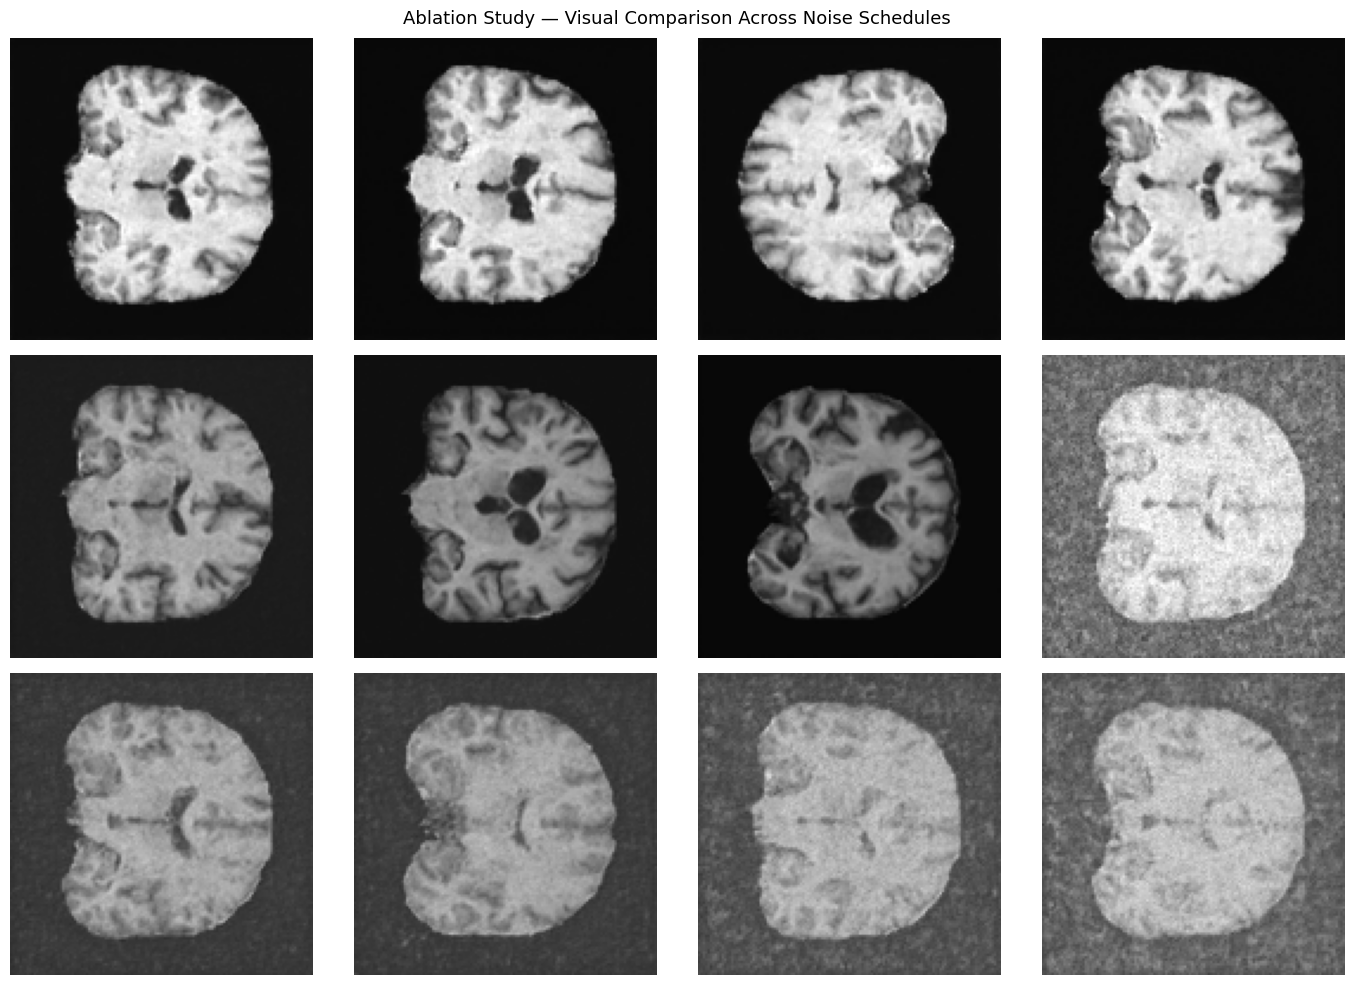

In [ ]:
# ── Cell 10: Visual comparison grid ───────────────────────────
import matplotlib.pyplot as plt
from PIL import Image

gen_dirs = {
    'Cosine T=1000': '/content/drive/MyDrive/Dissertation2026/ddpm-coronal-v3_output/fid_generated_100_subset',
    'Linear T=1000': '/content/drive/MyDrive/Dissertation2026/ablation_linear_1000_gen',
    'Cosine T=500':  '/content/drive/MyDrive/Dissertation2026/ablation_cosine_500_gen',
}

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Ablation Study — Visual Comparison Across Noise Schedules', fontsize=13)

for row, (name, gen_dir) in enumerate(gen_dirs.items()):
    files = sorted(os.listdir(gen_dir))[:4]
    for col, f in enumerate(files):
        img = Image.open(os.path.join(gen_dir, f))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(name, fontsize=10, rotation=90,
                                       labelpad=50, va='center')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dissertation2026/ablation_visual_comparison.png', dpi=150)
plt.show()